In [26]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost openpyxl textblob transformers torch -q

In [27]:
# =============================================================================
# CELL 2: LOAD DATA
# =============================================================================

# Load data
df = pd.read_csv('../data/raw/churn_data.csv')

print(f"📊 Shape of dataset: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")
print("\n🔍 Preview Data:")
df.head()

📊 Shape of dataset: (36992, 28)
📋 Columns: ['age', 'gender', 'security_no', 'region_category', 'joining_date', 'joined_through_referral', 'referral_id', 'preferred_offer_types', 'medium_of_operation', 'internet_option', 'last_visit_time', 'days_since_last_login', 'avg_session_duration', 'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet', 'used_special_discount', 'offer_application_preference', 'past_complaint', 'complaint_status', 'feedback', 'churn', 'plan_tier', 'logins_90d', 'active_days_90d', 'api_calls_90d', 'session_minutes_90d', 'days_since_active']

🔍 Preview Data:


,age,gender,security_no,region_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,...,past_complaint,complaint_status,feedback,churn,plan_tier,logins_90d,active_days_90d,api_calls_90d,session_minutes_90d,days_since_active
0,18,F,XW0DQ7H,Village,17-08-2017,No,xxxxxxxx,Gift Vouchers/Coupons,?,Wi-Fi,...,No,Not Applicable,Products always in Stock,0,Enterprise,46,33,8793,1027.11,2
1,32,F,5K0N3X1,City,28-08-2017,?,CID21329,Gift Vouchers/Coupons,Desktop,Mobile_Data,...,Yes,Solved,Quality Customer Care,0,Enterprise,37,30,8605,862.65,1
2,44,F,1F2TCL3,Town,11-11-2016,Yes,CID12313,Gift Vouchers/Coupons,Desktop,Wi-Fi,...,Yes,Solved in Follow-up,Poor Website,1,Basic,17,17,267,411.37,16
3,37,M,VJGJ33N,City,29-10-2016,Yes,CID3793,Gift Vouchers/Coupons,Desktop,Mobile_Data,...,Yes,Unsolved,Poor Website,1,Basic,8,8,227,215.77,20
4,31,F,SVZXCWB,City,12-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,Mobile_Data,...,Yes,Solved,Poor Website,1,Basic,13,11,294,231.94,2


In [28]:
# =============================================================================
# CELL 3: DATA CLEANING & PREPROCESSING
# =============================================================================

# 1. Simpan data asli untuk referensi di report nanti
df_original = df.copy()

# 2. Menangani nilai yang tidak wajar (string error)
df.replace({'?': np.nan, 'Unknown': np.nan, 'Error': np.nan}, inplace=True)

# =============================================================================
# 🔥 3. HANDLE OUTLIERS & INVALID VALUES (TAMBAHAN PENTING)
# =============================================================================

# Konversi kolom numerik (paksa string → angka, error jadi NaN)
cols_to_convert = [
    'days_since_last_login',
    'avg_session_duration',
    'avg_frequency_login_days',
    'points_in_wallet',
    'session_minutes_90d'
]

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --- days_since_last_login ---
df.loc[df['days_since_last_login'] < 0, 'days_since_last_login'] = np.nan

# --- avg_session_duration ---
df.loc[(df['avg_session_duration'] < 0) |
       (df['avg_session_duration'] > 10000), 'avg_session_duration'] = np.nan

# --- avg_frequency_login_days ---
df.loc[(df['avg_frequency_login_days'] < 0) |
       (df['avg_frequency_login_days'] > 365), 'avg_frequency_login_days'] = np.nan

# --- points_in_wallet ---
df.loc[(df['points_in_wallet'] < 0) |
       (df['points_in_wallet'] > 1_000_000), 'points_in_wallet'] = np.nan

# --- session_minutes_90d ---
df.loc[df['session_minutes_90d'] > 130000, 'session_minutes_90d'] = np.nan


# =============================================================================
# 4. Feature Selection (Hapus fitur yang tidak relevan)
# =============================================================================
cols_to_drop = ['security_no', 'referral_id', 'last_visit_time']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# =============================================================================
# 5. Transformasi Tanggal
# =============================================================================
df['joining_date'] = pd.to_datetime(df['joining_date'], format='%d-%m-%Y', errors='coerce')
reference_date = pd.to_datetime('2018-01-01')
df['days_since_joined'] = (reference_date - df['joining_date']).dt.days
df.drop('joining_date', axis=1, inplace=True)

# =============================================================================
# 6. Simpan kolom feedback untuk NLP
# =============================================================================
feedback_data = df['feedback'].fillna('').astype(str).copy()

# =============================================================================
# 7. Handling Missing Values
# =============================================================================
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if col != 'feedback':
        df[col] = df[col].fillna(df[col].mode()[0])

# =============================================================================
# 8. EXPORT HASIL PREPROCESSING
# =============================================================================

# Simpan dataset yang sudah dibersihkan
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/cleaned_churn_data.csv', index=False)

print("💾 Data berhasil disimpan:")
print("- cleaned_churn_data.csv")

# =============================================================================
# DONE
# =============================================================================
print("✅ Data Cleaning + Outlier Handling Selesai!")
print(f"📊 Total baris: {len(df)}")
print(f"📋 Total kolom: {len(df.columns)}")

💾 Data berhasil disimpan:
- cleaned_churn_data.csv
✅ Data Cleaning + Outlier Handling Selesai!
📊 Total baris: 36992
📋 Total kolom: 25


In [ ]:
# =============================================================================
# CELL 4: ANN SENTIMENT ANALYSIS MENGGUNAKAN PRE-TRAINED TRANSFORMER (BERT)
# =============================================================================

from transformers import pipeline
import pandas as pd
import time
import torch

print("=" * 70)
print("⏳ Memuat model ANN (Transformer) untuk Analisis Sentimen...")
print("=" * 70)

# Cek device yang tersedia (Gunakan GPU jika ada, jika tidak CPU)
device_id = 0 if torch.cuda.is_available() else -1

# Menggunakan model pre-trained BERT multilingual yang mengembalikan rating 1 sampai 5 bintang
sentiment_pipeline = pipeline(
    "sentiment-analysis", 
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    device=device_id 
)
print("✅ Model ANN berhasil dimuat!")

def analyze_sentiment_ann(texts):
    print(f"\n🚀 Menganalisis {len(texts)} feedback menggunakan ANN (BERT)...")
    start_time = time.time()
    
    # Mapping output BERT (1-5 stars) ke kategori dataset Anda
    label_map = {
        '1 star': ('Sangat Kecewa', 1),
        '2 stars': ('Kecewa', 2),
        '3 stars': ('Biasa', 3),
        '4 stars': ('Puas', 4),
        '5 stars': ('Sangat Puas', 5)
    }
    
    results = []
    batch_size = 100 # Proses per 100 baris untuk efisiensi memori
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]
        
        # Konversi ke string dan batasi karakter agar tidak melebihi limit dimensi tensor BERT
        batch_texts = [str(t)[:512] if pd.notnull(t) else "" for t in batch_texts]
        
        # Inferensi ke ANN Pipeline
        batch_results = sentiment_pipeline(batch_texts)
        
        for res in batch_results:
            kategori, score = label_map.get(res['label'], ('Biasa', 3))
            results.append({
                "kategori": kategori,
                "score": score,
                "confidence": res['score'],
                "raw_score": res['score'] * score
            })
            
        # Progress tracking
        if (i + batch_size) % 5000 == 0 or (i + batch_size) >= len(texts):
            current = min(i + batch_size, len(texts))
            pct = (current / len(texts)) * 100
            print(f"   Progress: {current}/{len(texts)} ({pct:.1f}%)")
            
    elapsed = time.time() - start_time
    print(f"\n✅ Selesai! Total waktu: {elapsed:.2f} detik ({elapsed/60:.2f} menit)")
    return results

# =========================
# EKSEKUSI KE DATA FEEDBACK
# =========================

# Jalankan model ANN pada kolom feedback_data
sentiment_results = analyze_sentiment_ann(feedback_data.tolist())

# Tambahkan hasilnya kembali ke DataFrame utama
df["sentiment_kategori"] = [r["kategori"] for r in sentiment_results]
df["sentiment_score"] = [r["score"] for r in sentiment_results]
df["sentiment_confidence"] = [r["confidence"] for r in sentiment_results]
df["sentiment_raw_score"] = [r["raw_score"] for r in sentiment_results]

# Hapus kolom feedback asli jika diperlukan
df.drop("feedback", axis=1, inplace=True, errors="ignore")

# =========================
# HASIL DISTRIBUSI SENTIMEN
# =========================
print("\n" + "=" * 70)
print("📊 DISTRIBUSI SENTIMEN (ANN - BERT)")
print("=" * 70)

sentiment_dist = df["sentiment_kategori"].value_counts()

for kategori in ["Sangat Puas", "Puas", "Biasa", "Kecewa", "Sangat Kecewa"]:
    count = sentiment_dist.get(kategori, 0)
    pct = (count / len(df)) * 100
    print(f"  {kategori:15s}: {count:5d} ({pct:5.1f}%)")

print("=" * 70)


/Users/irene/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


⏳ Memuat model ANN (Transformer) untuk Analisis Sentimen...


Device set to use cpu


✅ Model ANN berhasil dimuat!

🚀 Menganalisis 36992 feedback menggunakan ANN (BERT)...


: 

⚠️ Kolom 'sentiment_kategori' tidak ditemukan. Melewati hasil sentiment sebenarnya.
   Untuk menghitung sentimen, jalankan CELL 4 dengan RUN_SENTIMENT=True (pastikan resource cukup).


/var/folders/jp/gnrn50h95d74jv3rbb8fzm2h0000gn/T/ipykernel_55797/2524939574.py:42: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


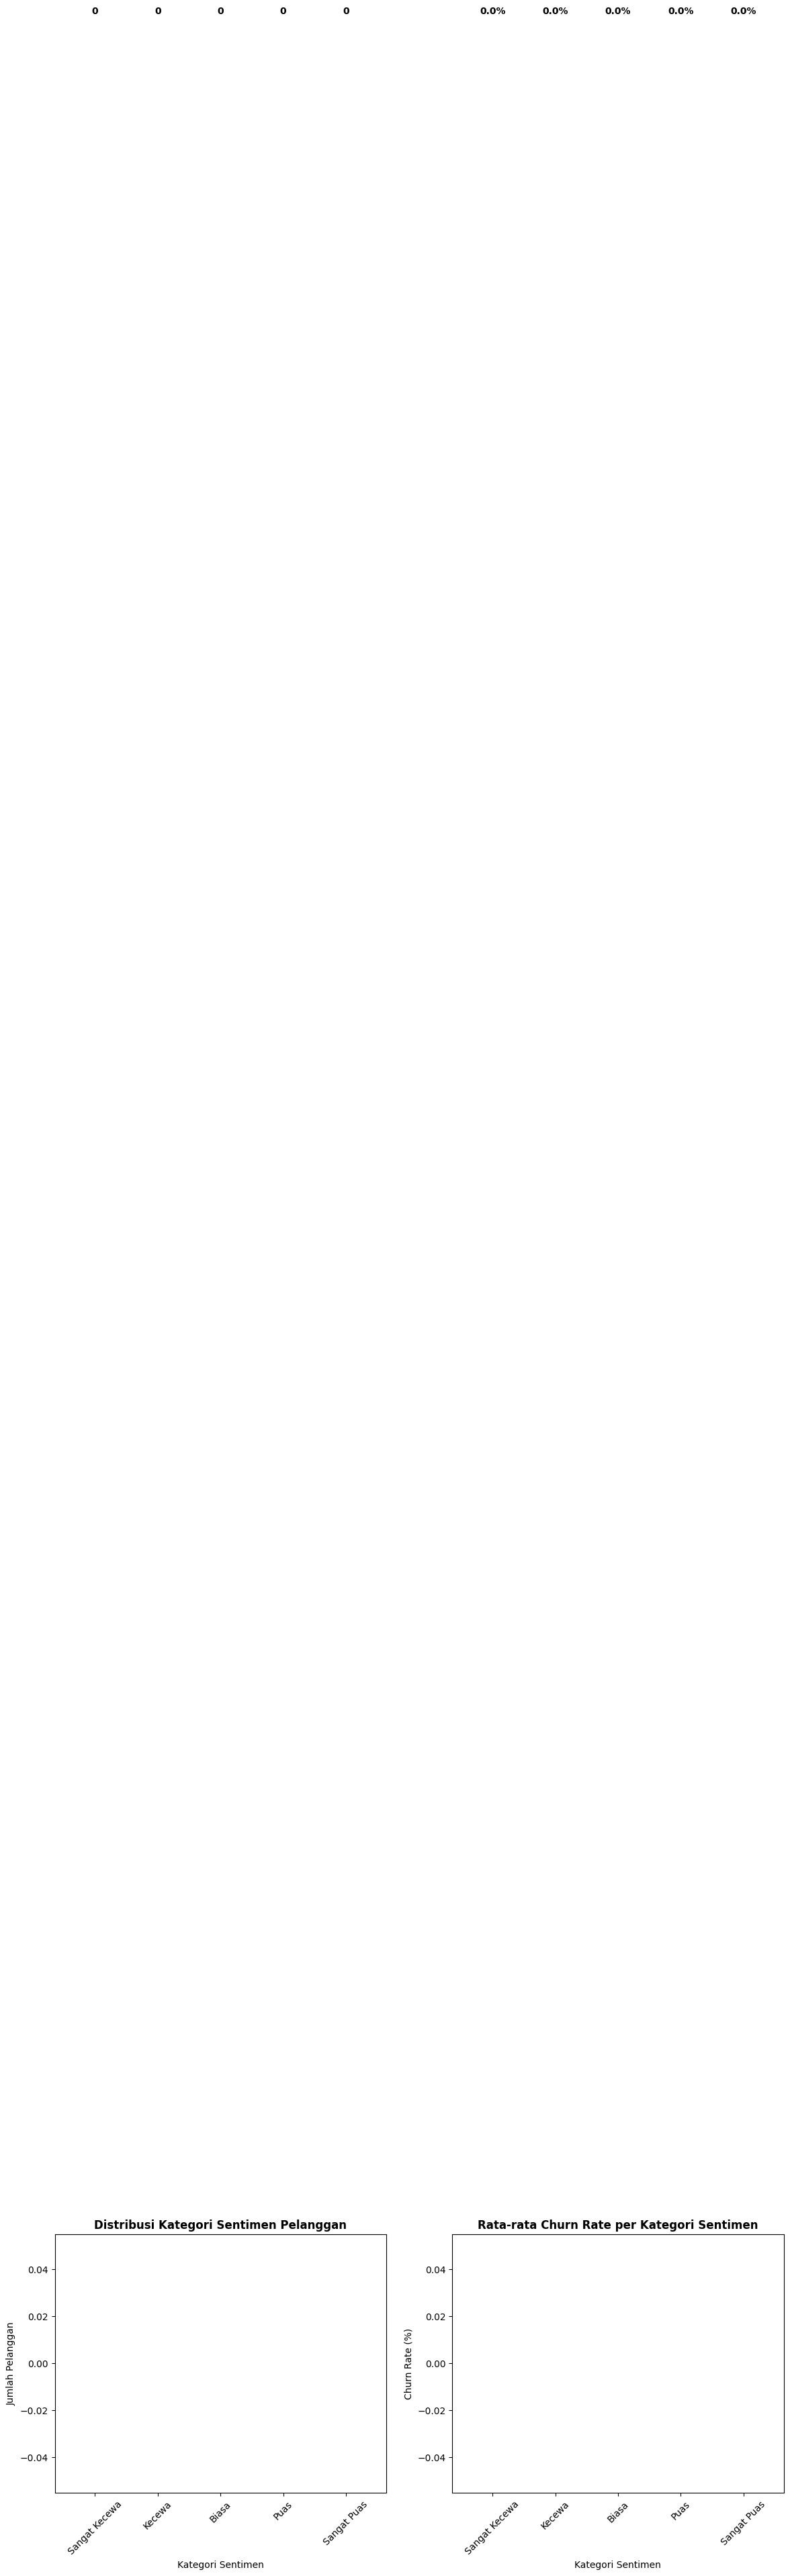


📈 Insight: Pelanggan dengan sentimen negatif cenderung memiliki churn rate lebih tinggi (jika tersedia).


In [ ]:
# =============================================================================
# CELL 5: VISUALISASI DISTRIBUSI SENTIMEN
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribusi Kategori Sentimen
colors_sentiment = ['#FF6B6B', '#FFA94D', '#FFE066', '#69DB7C', '#51CF66']
sentiment_order = ['Sangat Kecewa', 'Kecewa', 'Biasa', 'Puas', 'Sangat Puas']

sentiment_counts = df['sentiment_kategori'].value_counts().reindex(sentiment_order, fill_value=0)

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors_sentiment)
axes[0].set_title('Distribusi Kategori Sentimen Pelanggan', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kategori Sentimen')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].tick_params(axis='x', rotation=45)

# Tambahkan nilai di atas bar
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Plot 2: Sentimen vs Churn
sentiment_churn = df.groupby('sentiment_kategori')['churn'].mean().reindex(sentiment_order, fill_value=0) * 100

axes[1].bar(sentiment_churn.index, sentiment_churn.values, color=colors_sentiment)
axes[1].set_title('Rata-rata Churn Rate per Kategori Sentimen', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kategori Sentimen')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

# Tambahkan nilai di atas bar
for i, v in enumerate(sentiment_churn.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📈 Insight: Pelanggan dengan sentimen negatif cenderung memiliki churn rate lebih tinggi!")

In [ ]:
# =============================================================================
# CELL 6: ENCODING & SPLITTING DATA
# =============================================================================

# Simpan data untuk report sebelum encoding
df_for_report = df.copy()

# Ensure 'churn' column is numeric and handle NaNs if any
# Convert 'churn' to numeric, coercing errors to NaN
df['churn'] = pd.to_numeric(df['churn'], errors='coerce')

# Fill NaNs in 'churn' with the mode, but be careful if mode itself is NaN (i.e., all values are NaN)
if df['churn'].isnull().all():
    print("WARNING: The 'churn' column contains only NaN values after conversion. Setting all to 0.")
    df['churn'] = 0 # Default to 0 (Not Churn) if all are NaN
elif df['churn'].isnull().any():
    churn_mode = df['churn'].mode()[0]
    df['churn'] = df['churn'].fillna(churn_mode)
    print(f"INFO: Filled NaN values in 'churn' with mode: {int(churn_mode)}")

# 1. Encode kolom kategorikal
cat_cols = df.select_dtypes(include=['object']).columns
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# 2. Definisikan X dan y
X = df.drop('churn', axis=1)
y = df['churn']

# Simpan nama fitur
feature_names = X.columns.tolist()

# 3. Split data (70:30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Simpan index untuk report
test_indices = X_test.index.tolist()

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data Encoding & Splitting Selesai!")
print(f"📊 Training set: {X_train_scaled.shape[0]} samples")
print(f"📊 Test set: {X_test_scaled.shape[0]} samples")
print(f"📋 Jumlah fitur: {X_train_scaled.shape[1]}")

✅ Data Encoding & Splitting Selesai!
📊 Training set: 25894 samples
📊 Test set: 11098 samples
📋 Jumlah fitur: 24


In [ ]:
# =============================================================================
# CELL 7: MODEL TRAINING (XGBoost)
# =============================================================================

# Inisialisasi model XGBoost
xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

print("🔄 Training model XGBoost...")
xgb_model.fit(X_train_scaled, y_train)
print("✅ Model training selesai!")

# Prediksi
y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Prediksi untuk semua data (untuk report)
X_all_scaled = scaler.transform(X)
all_pred_proba = xgb_model.predict_proba(X_all_scaled)[:, 1]
all_pred = xgb_model.predict(X_all_scaled)

print(f"\n📊 Prediksi selesai untuk {len(all_pred)} pelanggan")

/Users/irene/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [14:38:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


/Users/irene/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [14:38:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


🔄 Training model XGBoost...
✅ Model training selesai!

📊 Prediksi selesai untuk 36992 pelanggan
✅ Model training selesai!

📊 Prediksi selesai untuk 36992 pelanggan


In [ ]:
# =============================================================================
# CELL 8: TRAINING MODEL — LOGISTIC REGRESSION
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

print("🔄 Handling remaining NaNs for Logistic Regression...")
# Logistic Regression cannot handle NaNs. We use an imputer to fill any gaps.
imputer = SimpleImputer(strategy='constant', fill_value=0)
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)

print("🔄 Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train_imputed, y_train)

# Prediksi
y_pred_lr       = lr_model.predict(X_test_imputed)
y_pred_proba_lr = lr_model.predict_proba(X_test_imputed)[:, 1]

print("✅ Logistic Regression selesai!")
print(f"   Training samples : {X_train_imputed.shape[0]}")
print(f"   Test samples     : {X_test_imputed.shape[0]}")

🔄 Handling remaining NaNs for Logistic Regression...
🔄 Training Logistic Regression...
✅ Logistic Regression selesai!
   Training samples : 25894
   Test samples     : 11098


In [ ]:
# =============================================================================
# CELL 9: TRAINING MODEL — RANDOM FOREST
# =============================================================================

from sklearn.ensemble import RandomForestClassifier

print("🔄 Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf       = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("✅ Random Forest selesai!")
print(f"   Training samples : {X_train_scaled.shape[0]}")
print(f"   Test samples     : {X_test_scaled.shape[0]}")


🔄 Training Random Forest...
✅ Random Forest selesai!
   Training samples : 25894
   Test samples     : 11098
✅ Random Forest selesai!
   Training samples : 25894
   Test samples     : 11098


In [ ]:
# =============================================================================
# CELL 10: EVALUASI MODEL
# =============================================================================

# 1. Classification Report
print("=" * 60)
print("📊 CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Not Churn', 'Churn']))

# 2. ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n🎯 ROC-AUC Score: {roc_auc:.4f}")

# 3. Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature Importance (Top 15)
importances = xgb_model.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=True).tail(15)

axes[1].barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
axes[1].set_title('Top 15 Feature Importances', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

📊 CLASSIFICATION REPORT


📊 CLASSIFICATION REPORT


NameError: name 'classification_report' is not defined

In [ ]:
# =============================================================================
# CELL 11: EVALUASI MODEL — LOGISTIC REGRESSION
# =============================================================================

from sklearn.metrics import classification_report, roc_auc_score

print("=" * 60)
print("📊 CLASSIFICATION REPORT — LOGISTIC REGRESSION")
print("=" * 60)
print(classification_report(y_test, y_pred_lr, target_names=["Not Churn", "Churn"]))

roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
print(f"🎯 ROC-AUC Score: {roc_auc_lr:.4f}")


📊 CLASSIFICATION REPORT — LOGISTIC REGRESSION
              precision    recall  f1-score   support

   Not Churn       0.83      0.90      0.86      5094
       Churn       0.91      0.85      0.88      6004

    accuracy                           0.87     11098
   macro avg       0.87      0.87      0.87     11098
weighted avg       0.87      0.87      0.87     11098

🎯 ROC-AUC Score: 0.9505


In [ ]:
# =============================================================================
# CELL 12: EVALUASI MODEL — RANDOM FOREST
# =============================================================================

from sklearn.metrics import classification_report, roc_auc_score

print("=" * 60)
print("📊 CLASSIFICATION REPORT — RANDOM FOREST")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=["Not Churn", "Churn"]))

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"🎯 ROC-AUC Score: {roc_auc_rf:.4f}")


📊 CLASSIFICATION REPORT — RANDOM FOREST
              precision    recall  f1-score   support

   Not Churn       0.91      0.94      0.93      5094
       Churn       0.95      0.92      0.94      6004

    accuracy                           0.93     11098
   macro avg       0.93      0.93      0.93     11098
weighted avg       0.93      0.93      0.93     11098

🎯 ROC-AUC Score: 0.9748


🔄 Menghitung SHAP values untuk XGBoost...
✅ SHAP values dihitung! Shape: (11098, 27)

📊 Plot 1: SHAP Beeswarm Summary Plot


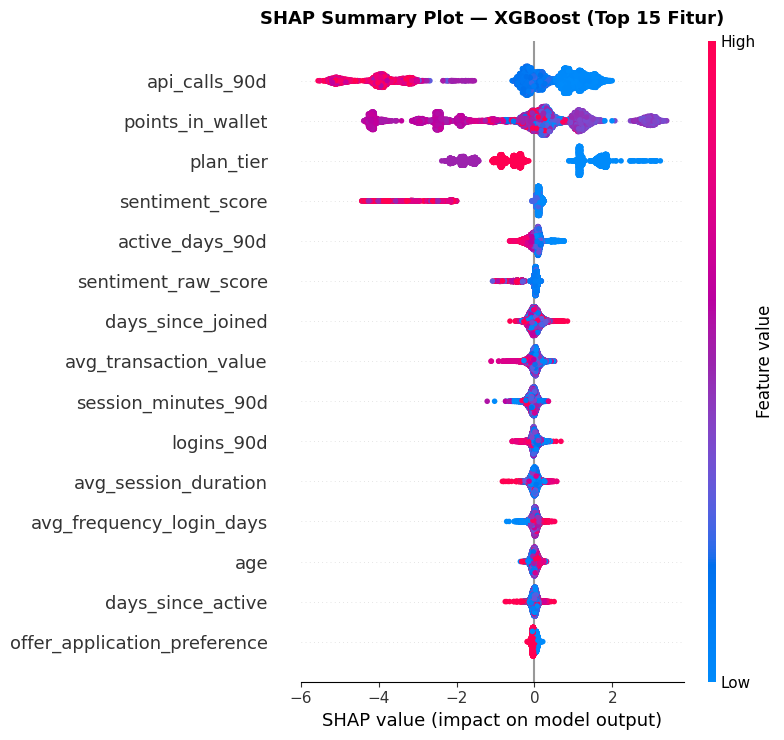


📊 Plot 2: SHAP Feature Importance (Mean |SHAP|)


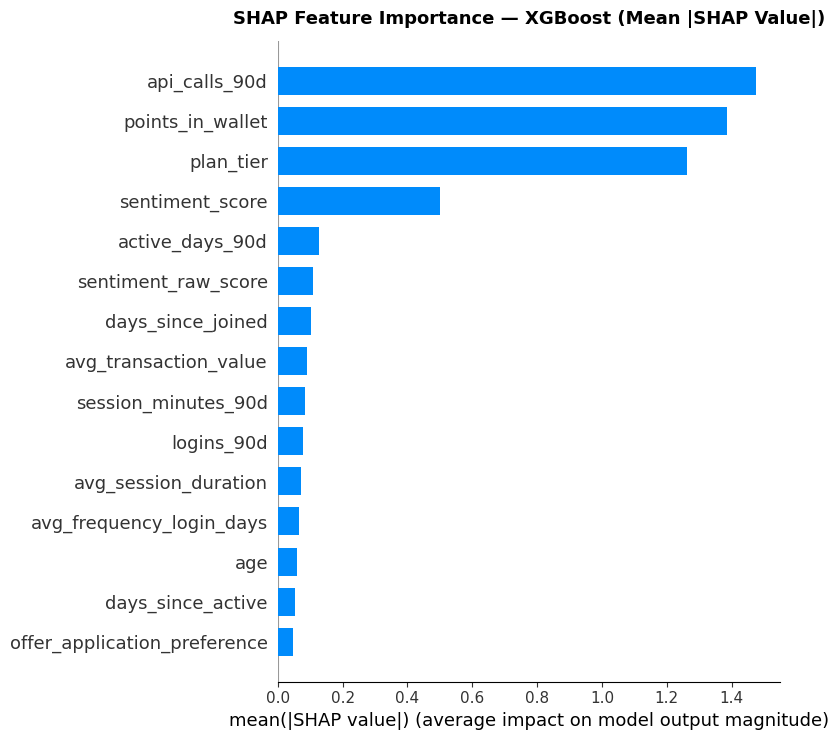


📊 Plot 3: Waterfall — Pelanggan risiko churn tertinggi


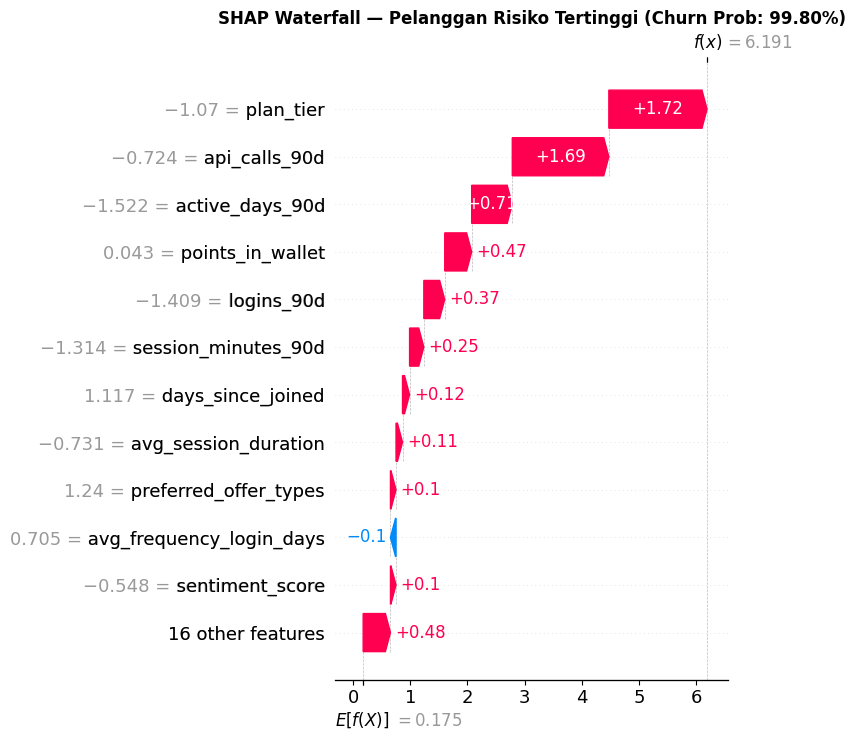


🔍 TOP 10 FITUR BERDASARKAN SHAP (XGBoost)
              Feature  Mean |SHAP|
        api_calls_90d     1.475214
     points_in_wallet     1.386930
            plan_tier     1.263683
      sentiment_score     0.501839
      active_days_90d     0.127765
  sentiment_raw_score     0.110100
    days_since_joined     0.102808
avg_transaction_value     0.091814
  session_minutes_90d     0.083776
           logins_90d     0.076557

✅ SHAP analysis selesai!


In [ ]:
# =============================================================================
# CELL 13: SHAP EXPLAINABILITY — XGBoost
# =============================================================================

import importlib, subprocess
if importlib.util.find_spec("shap") is None:
    print("📦 Installing shap...")
    subprocess.run(["pip", "install", "shap", "-q"], check=True)
    print("✅ shap installed!")

import shap
import pandas as pd
import matplotlib.pyplot as plt

print("🔄 Menghitung SHAP values untuk XGBoost...")
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)
X_test_df   = pd.DataFrame(X_test_scaled, columns=feature_names)
print(f"✅ SHAP values dihitung! Shape: {shap_values.shape}")

# ── Plot 1: Beeswarm Summary Plot ────────────────────────────────────────────
print("\n📊 Plot 1: SHAP Beeswarm Summary Plot")
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_df, plot_type="dot", max_display=15, show=False)
plt.title("SHAP Summary Plot — XGBoost (Top 15 Fitur)", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# ── Plot 2: Bar Plot (Mean |SHAP|) ───────────────────────────────────────────
print("\n📊 Plot 2: SHAP Feature Importance (Mean |SHAP|)")
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test_df, plot_type="bar", max_display=15, show=False)
plt.title("SHAP Feature Importance — XGBoost (Mean |SHAP Value|)", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# ── Plot 3: Waterfall untuk pelanggan risiko tertinggi ───────────────────────
print("\n📊 Plot 3: Waterfall — Pelanggan risiko churn tertinggi")
high_risk_idx = y_pred_proba.argmax()
shap_explanation = shap.Explanation(
    values        = shap_values[high_risk_idx],
    base_values   = explainer.expected_value,
    data          = X_test_df.iloc[high_risk_idx].values,
    feature_names = feature_names
)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation, max_display=12, show=False)
plt.title(
    f"SHAP Waterfall — Pelanggan Risiko Tertinggi (Churn Prob: {y_pred_proba[high_risk_idx]:.2%})",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

# ── Tabel Top Fitur ───────────────────────────────────────────────────────────
mean_shap = pd.DataFrame({
    "Feature"    : feature_names,
    "Mean |SHAP|": abs(shap_values).mean(axis=0)
}).sort_values("Mean |SHAP|", ascending=False).reset_index(drop=True)

print("\n" + "="*50)
print("🔍 TOP 10 FITUR BERDASARKAN SHAP (XGBoost)")
print("="*50)
print(mean_shap.head(10).to_string(index=False))
print("="*50)
print("\n✅ SHAP analysis selesai!")


In [ ]:
# =============================================================================
# CELL 14: FUNGSI GENERATE PROBLEM & SOLUTION
# =============================================================================

def get_problem_and_solution(row, churn_prob, sentiment_kategori):
    """
    Fungsi untuk menentukan masalah dan solusi berdasarkan data pelanggan
    """
    problems = []
    solutions = []

    # 1. Analisis berdasarkan Churn Probability
    if churn_prob >= 0.7:
        problems.append("Risiko churn SANGAT TINGGI (>70%)")
        solutions.append("Prioritas tinggi: Hubungi pelanggan segera untuk retention program")
    elif churn_prob >= 0.5:
        problems.append("Risiko churn TINGGI (50-70%)")
        solutions.append("Tawarkan promo khusus atau loyalty reward")
    elif churn_prob >= 0.3:
        problems.append("Risiko churn SEDANG (30-50%)")
        solutions.append("Monitor aktivitas dan kirim engagement email")

    # 2. Analisis berdasarkan Sentimen
    if sentiment_kategori == 'Sangat Kecewa':
        problems.append("Pelanggan sangat tidak puas dengan layanan")
        solutions.append("Eskalasi ke tim customer success untuk penanganan personal")
    elif sentiment_kategori == 'Kecewa':
        problems.append("Pelanggan menunjukkan ketidakpuasan")
        solutions.append("Kirim survey untuk identifikasi keluhan spesifik")

    # 3. Analisis berdasarkan data lainnya (jika ada)
    # Contoh: cek kolom complaint, points_in_wallet, dll
    try:
        if 'complaint_status' in row.index and row.get('complaint_status', 0) == 1:
            problems.append("Ada keluhan yang belum terselesaikan")
            solutions.append("Prioritaskan penyelesaian keluhan pelanggan")

        if 'points_in_wallet' in row.index and row.get('points_in_wallet', 0) > 500:
            solutions.append("Ingatkan pelanggan untuk redeem points yang tersedia")

        if 'days_since_joined' in row.index:
            days = row.get('days_since_joined', 0)
            if days > 365:
                solutions.append("Berikan loyalty bonus untuk pelanggan setia")
    except:
        pass

    # Default jika tidak ada masalah
    if not problems:
        problems.append("Tidak ada masalah signifikan terdeteksi")
        solutions.append("Pertahankan kualitas layanan dan engagement rutin")

    return "; ".join(problems), "; ".join(solutions)

def get_sentiment_conclusion(sentiment_kategori, sentiment_score, churn_prob):
    """
    Fungsi untuk membuat kesimpulan sentimen pelanggan
    """
    if sentiment_kategori == 'Sangat Puas':
        conclusion = f"Pelanggan SANGAT PUAS dengan layanan (Score: {sentiment_score}/5). "
        if churn_prob < 0.3:
            conclusion += "Kemungkinan menjadi brand advocate."
        else:
            conclusion += "Namun perlu monitoring karena ada faktor risiko lain."

    elif sentiment_kategori == 'Puas':
        conclusion = f"Pelanggan PUAS dengan layanan (Score: {sentiment_score}/5). "
        if churn_prob < 0.3:
            conclusion += "Potensi untuk ditingkatkan menjadi loyal customer."
        else:
            conclusion += "Ada faktor lain yang perlu diperhatikan."

    elif sentiment_kategori == 'Biasa':
        conclusion = f"Pelanggan NETRAL/BIASA (Score: {sentiment_score}/5). "
        conclusion += "Perlu upaya untuk meningkatkan engagement dan kepuasan."

    elif sentiment_kategori == 'Kecewa':
        conclusion = f"Pelanggan KECEWA dengan layanan (Score: {sentiment_score}/5). "
        conclusion += "PERHATIAN: Perlu tindakan untuk memperbaiki pengalaman pelanggan."

    else:  # Sangat Kecewa
        conclusion = f"Pelanggan SANGAT KECEWA (Score: {sentiment_score}/5). "
        conclusion += "URGENT: Butuh penanganan segera untuk mencegah churn!"

    return conclusion

print("✅ Fungsi Problem & Solution berhasil dibuat!")

✅ Fungsi Problem & Solution berhasil dibuat!


In [ ]:
# =============================================================================
# CELL 15: GENERATE COMPREHENSIVE REPORT DATAFRAME
# =============================================================================

print("🔄 Generating comprehensive report...")

# Buat DataFrame untuk report
report_df = pd.DataFrame()

# 1. Informasi Identitas (dari data original jika ada)
if 'customer_id' in df_original.columns:
    report_df['Customer_ID'] = df_original['customer_id']
else:
    report_df['Customer_ID'] = [f"CUST_{str(i).zfill(5)}" for i in range(len(df))]

if 'Name' in df_original.columns:
    report_df['Nama'] = df_original['Name']
elif 'name' in df_original.columns:
    report_df['Nama'] = df_original['name']
else:
    report_df['Nama'] = [f"Customer {i+1}" for i in range(len(df))]

# 2. Data Gender dan Region (jika ada)
for col in ['gender', 'region', 'membership_category']:
    if col in df_original.columns:
        report_df[col.replace('_', ' ').title()] = df_original[col]

# 3. Churn Probability
report_df['Churn_Probability'] = all_pred_proba
report_df['Churn_Probability_Percent'] = (all_pred_proba * 100).round(2)
report_df['Predicted_Churn'] = ['Ya' if p == 1 else 'Tidak' for p in all_pred]
report_df['Actual_Churn'] = ['Ya' if c == 1 else 'Tidak' for c in y.values]

# 4. Risk Level
def get_risk_level(prob):
    if prob >= 0.7:
        return 'TINGGI'
    elif prob >= 0.5:
        return 'SEDANG-TINGGI'
    elif prob >= 0.3:
        return 'SEDANG'
    else:
        return 'RENDAH'

report_df['Risk_Level'] = report_df['Churn_Probability'].apply(get_risk_level)

# 5. Sentiment Analysis Results
report_df['Sentiment_Kategori'] = df_for_report['sentiment_kategori']
report_df['Sentiment_Score'] = df_for_report['sentiment_score']
report_df['Sentiment_Confidence'] = (df_for_report['sentiment_confidence'] * 100).round(2)

# 6. Original Feedback
report_df['Feedback_Original'] = feedback_data.values

# 7. Problem, Solution, dan Kesimpulan
problems_list = []
solutions_list = []
conclusions_list = []

for idx in range(len(report_df)):
    row = df_for_report.iloc[idx]
    churn_prob = report_df['Churn_Probability'].iloc[idx]
    sentiment_kat = report_df['Sentiment_Kategori'].iloc[idx]
    sentiment_score = report_df['Sentiment_Score'].iloc[idx]

    problem, solution = get_problem_and_solution(row, churn_prob, sentiment_kat)
    conclusion = get_sentiment_conclusion(sentiment_kat, sentiment_score, churn_prob)

    problems_list.append(problem)
    solutions_list.append(solution)
    conclusions_list.append(conclusion)

report_df['Masalah'] = problems_list
report_df['Solusi'] = solutions_list
report_df['Kesimpulan_Sentiment'] = conclusions_list

print(f"✅ Report DataFrame berhasil dibuat dengan {len(report_df)} baris!")
print(f"📋 Kolom: {report_df.columns.tolist()}")
report_df.head()

🔄 Generating comprehensive report...
✅ Report DataFrame berhasil dibuat dengan 36992 baris!
📋 Kolom: ['Customer_ID', 'Nama', 'Gender', 'Churn_Probability', 'Churn_Probability_Percent', 'Predicted_Churn', 'Actual_Churn', 'Risk_Level', 'Sentiment_Kategori', 'Sentiment_Score', 'Sentiment_Confidence', 'Feedback_Original', 'Masalah', 'Solusi', 'Kesimpulan_Sentiment']


,Customer_ID,Nama,Gender,Churn_Probability,Churn_Probability_Percent,Predicted_Churn,Actual_Churn,Risk_Level,Sentiment_Kategori,Sentiment_Score,Sentiment_Confidence,Feedback_Original,Masalah,Solusi,Kesimpulan_Sentiment
0,CUST_00000,Customer 1,F,0.000080,0.010000,Tidak,Tidak,RENDAH,Sangat Puas,5,61.27,Products always in Stock,Tidak ada masalah signifikan terdeteksi,Ingatkan pelanggan untuk redeem points yang te...,Pelanggan SANGAT PUAS dengan layanan (Score: 5...
1,CUST_00001,Customer 2,F,0.000266,0.030000,Tidak,Tidak,RENDAH,Sangat Puas,5,55.06,Quality Customer Care,Tidak ada masalah signifikan terdeteksi,Ingatkan pelanggan untuk redeem points yang te...,Pelanggan SANGAT PUAS dengan layanan (Score: 5...
2,CUST_00002,Customer 3,F,0.978968,97.900002,Ya,Ya,TINGGI,Sangat Kecewa,1,58.91,Poor Website,Risiko churn SANGAT TINGGI (>70%); Pelanggan s...,Prioritas tinggi: Hubungi pelanggan segera unt...,Pelanggan SANGAT KECEWA (Score: 1/5). URGENT: ...
3,CUST_00003,Customer 4,M,0.994239,99.419998,Ya,Ya,TINGGI,Sangat Kecewa,1,58.91,Poor Website,Risiko churn SANGAT TINGGI (>70%); Pelanggan s...,Prioritas tinggi: Hubungi pelanggan segera unt...,Pelanggan SANGAT KECEWA (Score: 1/5). URGENT: ...
4,CUST_00004,Customer 5,F,0.971137,97.110001,Ya,Ya,TINGGI,Sangat Kecewa,1,58.91,Poor Website,Risiko churn SANGAT TINGGI (>70%); Pelanggan s...,Prioritas tinggi: Hubungi pelanggan segera unt...,Pelanggan SANGAT KECEWA (Score: 1/5). URGENT: ...


In [ ]:
# =============================================================================
# CELL 16: PREVIEW REPORT
# =============================================================================

# Tampilkan sample report
print("=" * 80)
print("📋 PREVIEW REPORT - 5 PELANGGAN DENGAN RISIKO TERTINGGI")
print("=" * 80)

high_risk = report_df.nlargest(5, 'Churn_Probability')

for idx, row in high_risk.iterrows():
    print(f"\n{'─' * 60}")
    print(f"👤 {row['Customer_ID']} | {row.get('Nama', 'N/A')}")
    print(f"{'─' * 60}")
    print(f"📊 Churn Probability: {row['Churn_Probability_Percent']}%")
    print(f"⚠️  Risk Level: {row['Risk_Level']}")
    print(f"😊 Sentimen: {row['Sentiment_Kategori']} (Score: {row['Sentiment_Score']}/5)")
    print(f"💬 Feedback: {row['Feedback_Original'][:100]}..." if len(str(row['Feedback_Original'])) > 100 else f"💬 Feedback: {row['Feedback_Original']}")
    print(f"\n❌ MASALAH: {row['Masalah']}")
    print(f"✅ SOLUSI: {row['Solusi']}")
    print(f"\n📝 KESIMPULAN: {row['Kesimpulan_Sentiment']}")

print(f"\n{'=' * 80}")

📋 PREVIEW REPORT - 5 PELANGGAN DENGAN RISIKO TERTINGGI

────────────────────────────────────────────────────────────
👤 CUST_12891 | Customer 12892
────────────────────────────────────────────────────────────
📊 Churn Probability: 99.80999755859375%
⚠️  Risk Level: TINGGI
😊 Sentimen: Sangat Kecewa (Score: 1/5)
💬 Feedback: Poor Customer Service

❌ MASALAH: Risiko churn SANGAT TINGGI (>70%); Pelanggan sangat tidak puas dengan layanan
✅ SOLUSI: Prioritas tinggi: Hubungi pelanggan segera untuk retention program; Eskalasi ke tim customer success untuk penanganan personal; Ingatkan pelanggan untuk redeem points yang tersedia; Berikan loyalty bonus untuk pelanggan setia

📝 KESIMPULAN: Pelanggan SANGAT KECEWA (Score: 1/5). URGENT: Butuh penanganan segera untuk mencegah churn!

────────────────────────────────────────────────────────────
👤 CUST_30985 | Customer 30986
────────────────────────────────────────────────────────────
📊 Churn Probability: 99.80999755859375%
⚠️  Risk Level: TINGGI
😊 Senti

In [ ]:
# =============================================================================
# CELL 17: EXPORT TO EXCEL DENGAN FORMATTING
# =============================================================================

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.chart import BarChart, PieChart, Reference
import os

def export_to_excel(report_df, filename='../reports/Churn_Analysis_Report.xlsx'):
    """
    Export report ke Excel dengan formatting yang rapi
    """

    # Buat workbook baru
    wb = Workbook()

    # =========================================================================
    # SHEET 1: SUMMARY
    # =========================================================================
    ws_summary = wb.active
    ws_summary.title = "Summary"

    # Header styling
    header_font = Font(bold=True, color='FFFFFF', size=12)
    header_fill = PatternFill(start_color='4472C4', end_color='4472C4', fill_type='solid')

    # Summary Statistics
    ws_summary['A1'] = "CHURN ANALYSIS REPORT"
    ws_summary['A1'].font = Font(bold=True, size=18)
    ws_summary['A2'] = f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"

    # Overall Statistics
    total_customers = len(report_df)
    total_high_risk = len(report_df[report_df['Risk_Level'] == 'TINGGI'])
    total_medium_risk = len(report_df[report_df['Risk_Level'].isin(['SEDANG', 'SEDANG-TINGGI'])])
    avg_churn_prob = report_df['Churn_Probability_Percent'].mean()

    stats = [
        ['STATISTIK UMUM', ''],
        ['Total Pelanggan', total_customers],
        ['Pelanggan Risiko Tinggi', total_high_risk],
        ['Pelanggan Risiko Sedang', total_medium_risk],
        ['Rata-rata Churn Probability', f"{avg_churn_prob:.2f}%"],
        ['', ''],
        ['DISTRIBUSI SENTIMEN', ''],
    ]

    # Tambahkan distribusi sentimen
    sentiment_dist = report_df['Sentiment_Kategori'].value_counts()
    for sent, count in sentiment_dist.items():
        stats.append([sent, count])

    for row_idx, (label, value) in enumerate(stats, start=4):
        ws_summary[f'A{row_idx}'] = label
        ws_summary[f'B{row_idx}'] = value
        if label in ['STATISTIK UMUM', 'DISTRIBUSI SENTIMEN']:
            ws_summary[f'A{row_idx}'].font = Font(bold=True, size=11)

    # =========================================================================
    # SHEET 2: FULL REPORT
    # =========================================================================
    ws_report = wb.create_sheet("Full Report")

    # Tulis header
    headers = report_df.columns.tolist()
    for col_idx, header in enumerate(headers, start=1):
        cell = ws_report.cell(row=1, column=col_idx, value=header)
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = Alignment(horizontal='center', vertical='center')

    # Tulis data
    for row_idx, row in enumerate(report_df.values, start=2):
        for col_idx, value in enumerate(row, start=1):
            cell = ws_report.cell(row=row_idx, column=col_idx, value=value)
            cell.alignment = Alignment(horizontal='left', vertical='center', wrap_text=True)

    # Conditional formatting untuk Risk Level
    risk_fills = {
        'TINGGI': PatternFill(start_color='FF6B6B', end_color='FF6B6B', fill_type='solid'),
        'SEDANG-TINGGI': PatternFill(start_color='FFA94D', end_color='FFA94D', fill_type='solid'),
        'SEDANG': PatternFill(start_color='FFE066', end_color='FFE066', fill_type='solid'),
        'RENDAH': PatternFill(start_color='69DB7C', end_color='69DB7C', fill_type='solid')
    }

    risk_col_idx = headers.index('Risk_Level') + 1
    for row_idx in range(2, len(report_df) + 2):
        cell = ws_report.cell(row=row_idx, column=risk_col_idx)
        if cell.value in risk_fills:
            cell.fill = risk_fills[cell.value]

    # Conditional formatting untuk Sentiment
    sentiment_fills = {
        'Sangat Kecewa': PatternFill(start_color='FF6B6B', end_color='FF6B6B', fill_type='solid'),
        'Kecewa': PatternFill(start_color='FFA94D', end_color='FFA94D', fill_type='solid'),
        'Biasa': PatternFill(start_color='FFE066', end_color='FFE066', fill_type='solid'),
        'Puas': PatternFill(start_color='69DB7C', end_color='69DB7C', fill_type='solid'),
        'Sangat Puas': PatternFill(start_color='51CF66', end_color='51CF66', fill_type='solid')
    }

    sentiment_col_idx = headers.index('Sentiment_Kategori') + 1
    for row_idx in range(2, len(report_df) + 2):
        cell = ws_report.cell(row=row_idx, column=sentiment_col_idx)
        if cell.value in sentiment_fills:
            cell.fill = sentiment_fills[cell.value]

    # Adjust column widths
    column_widths = {
        'Customer_ID': 15,
        'Nama': 20,
        'Churn_Probability_Percent': 12,
        'Risk_Level': 15,
        'Sentiment_Kategori': 15,
        'Feedback_Original': 50,
        'Masalah': 50,
        'Solusi': 60,
        'Kesimpulan_Sentiment': 70
    }

    for col_idx, header in enumerate(headers, start=1):
        width = column_widths.get(header, 15)
        ws_report.column_dimensions[ws_report.cell(row=1, column=col_idx).column_letter].width = width

    # =========================================================================
    # SHEET 3: HIGH RISK CUSTOMERS
    # =========================================================================
    ws_high_risk = wb.create_sheet("High Risk Customers")

    high_risk_df = report_df[report_df['Risk_Level'] == 'TINGGI'].copy()

    # Tulis header
    for col_idx, header in enumerate(headers, start=1):
        cell = ws_high_risk.cell(row=1, column=col_idx, value=header)
        cell.font = header_font
        cell.fill = PatternFill(start_color='C00000', end_color='C00000', fill_type='solid')
        cell.alignment = Alignment(horizontal='center')

    # Tulis data
    for row_idx, row in enumerate(high_risk_df.values, start=2):
        for col_idx, value in enumerate(row, start=1):
            cell = ws_high_risk.cell(row=row_idx, column=col_idx, value=value)

    # =========================================================================
    # SHEET 4: ACTION ITEMS
    # =========================================================================
    ws_actions = wb.create_sheet("Action Items")

    ws_actions['A1'] = "ACTION ITEMS - PRIORITAS TINGGI"
    ws_actions['A1'].font = Font(bold=True, size=14)

    action_headers = ['Customer_ID', 'Nama', 'Churn_Prob%', 'Sentimen', 'Masalah', 'Solusi Rekomendasi']
    for col_idx, header in enumerate(action_headers, start=1):
        cell = ws_actions.cell(row=3, column=col_idx, value=header)
        cell.font = header_font
        cell.fill = PatternFill(start_color='ED7D31', end_color='ED7D31', fill_type='solid')

    # Filter high risk dan negative sentiment
    priority_df = report_df[
        (report_df['Churn_Probability'] >= 0.5) |
        (report_df['Sentiment_Kategori'].isin(['Sangat Kecewa', 'Kecewa']))
    ].sort_values('Churn_Probability', ascending=False)

    for row_idx, (_, row) in enumerate(priority_df.iterrows(), start=4):
        ws_actions.cell(row=row_idx, column=1, value=row['Customer_ID'])
        ws_actions.cell(row=row_idx, column=2, value=row.get('Nama', 'N/A'))
        ws_actions.cell(row=row_idx, column=3, value=row['Churn_Probability_Percent'])
        ws_actions.cell(row=row_idx, column=4, value=row['Sentiment_Kategori'])
        ws_actions.cell(row=row_idx, column=5, value=row['Masalah'])
        ws_actions.cell(row=row_idx, column=6, value=row['Solusi'])

    # Adjust widths
    for col_idx, width in enumerate([15, 20, 12, 15, 50, 60], start=1):
        ws_actions.column_dimensions[ws_actions.cell(row=1, column=col_idx).column_letter].width = width

    # Simpan file
    wb.save(filename)
    print(f"✅ Report berhasil disimpan: {filename}")
    return filename

# Export report
import os
os.makedirs('../reports', exist_ok=True)
excel_filename = export_to_excel(report_df, '../reports/Churn_Analysis_Report.xlsx')

✅ Report berhasil disimpan: ../reports/Churn_Analysis_Report.xlsx


🔄 Menyiapkan Decision Tree & Cross Validation...

📊 HASIL CROSS-VALIDATION (10-Fold) - DECISION TREE
Skor Akurasi tiap Fold : [0.92046332 0.93166023 0.93050193 0.92432432 0.93008884 0.92313635
 0.93433758 0.92777134 0.93124759 0.93279258]
Rata-rata Akurasi      : 0.9286 (+/- 0.0087)

🏆 TOP 10 ATRIBUT PALING BERPENGARUH (HUBUNGAN KE TARGET)
                  Fitur  Tingkat Kepentingan
          api_calls_90d             0.707120
       points_in_wallet             0.289265
              plan_tier             0.002882
             logins_90d             0.000586
  avg_transaction_value             0.000148
    medium_of_operation             0.000000
  preferred_offer_types             0.000000
        region_category             0.000000
joined_through_referral             0.000000
                 gender             0.000000


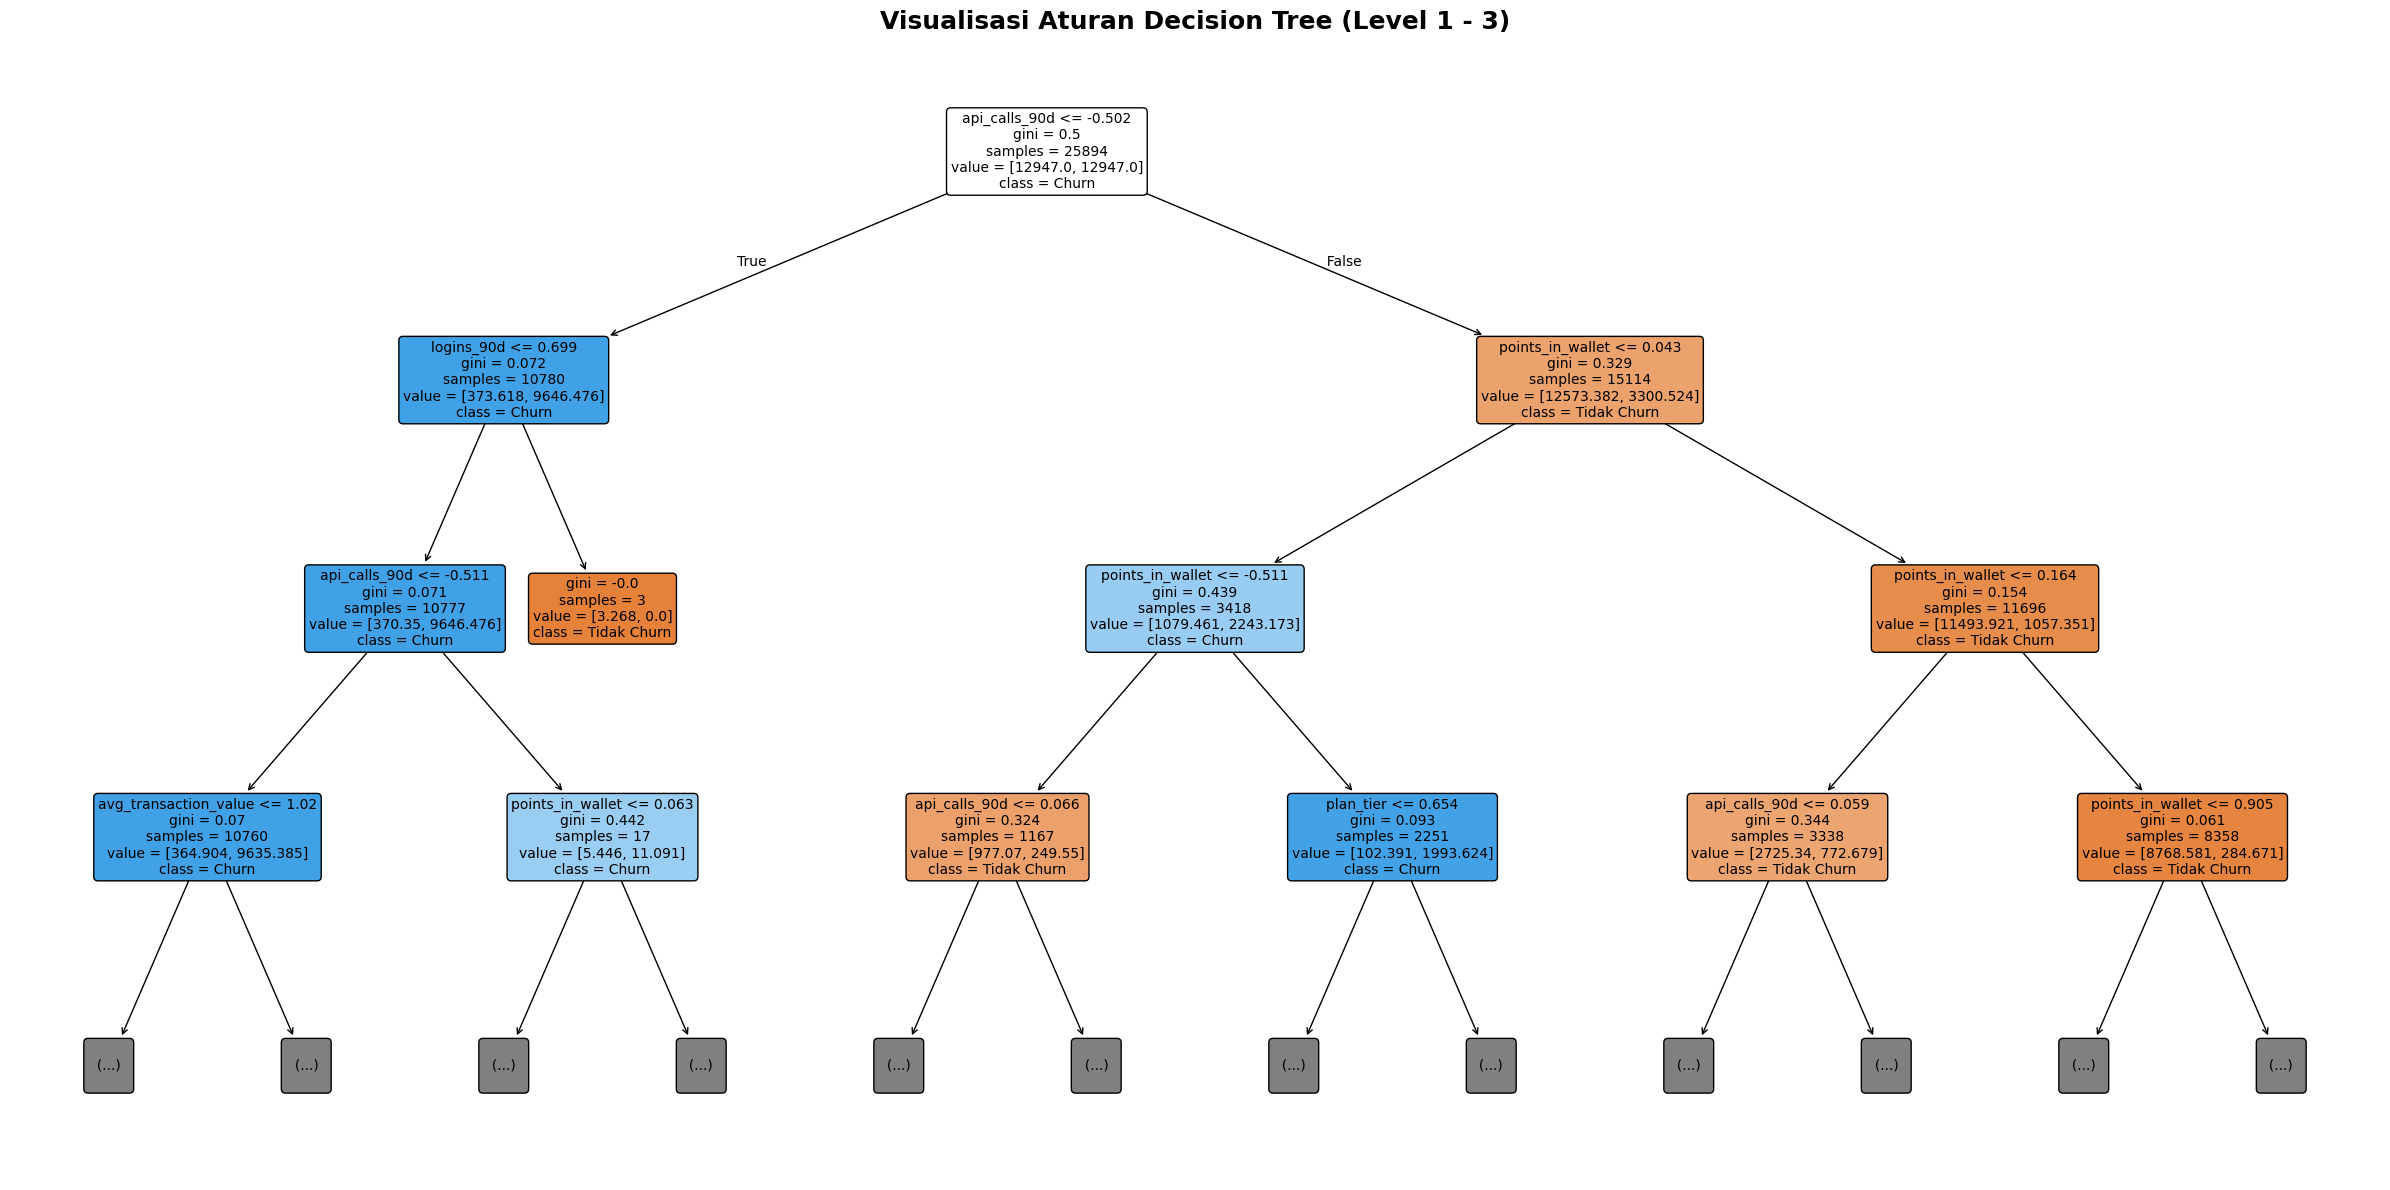

In [ ]:
# =============================================================================
# CELL 10: DECISION TREE, CROSS VALIDATION, & VISUALISASI
# =============================================================================
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score, StratifiedKFold
import pandas as pd
import numpy as np

print("🔄 Menyiapkan Decision Tree & Cross Validation...")

# 1. Inisialisasi Model Decision Tree
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
dt_model.fit(X_train_scaled, y_train)

# 2. Proses Cross-Validation (K-Fold = 10)
# Menggunakan StratifiedKFold untuk memastikan proporsi kelas target konsisten
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
# Menggunakan StratifiedKFold untuk memastikan proporsi kelas target konsisten
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(dt_model, X_train_scaled, y_train, cv=skf, scoring='accuracy')

print("\n" + "="*60)
print("📊 HASIL CROSS-VALIDATION (10-Fold) - DECISION TREE")
print("="*60)
print(f"Skor Akurasi tiap Fold : {cv_scores}")
print(f"Rata-rata Akurasi      : {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# 3. Menghitung Hubungan/Pentingnya Atribut (Feature Importance)
importances = dt_model.feature_importances_
feature_df = pd.DataFrame({'Fitur': feature_names, 'Tingkat Kepentingan': importances})
feature_df = feature_df.sort_values(by='Tingkat Kepentingan', ascending=False).head(10)

print("\n" + "="*60)
print("🏆 TOP 10 ATRIBUT PALING BERPENGARUH (HUBUNGAN KE TARGET)")
print("="*60)
print(feature_df.to_string(index=False))

# 4. Visualisasi Decision Tree (Pohon Keputusan)
plt.figure(figsize=(24, 12))
plot_tree(dt_model, 
          feature_names=feature_names,  
          class_names=['Tidak Churn', 'Churn'],
          filled=True, 
          rounded=True, 
          fontsize=10,
          max_depth=3)
plt.title('Visualisasi Aturan Decision Tree (Level 1 - 3)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


🔄 Menghitung Prediksi Cross-Validation untuk Matriks Evaluasi...

📈 METRIK EVALUASI: SENSITIVITY & SPECIFICITY (10-Fold CV)
Sensitivity (Recall Positif) : 0.8981 (89.8%)
Specificity (Recall Negatif) : 0.9646 (96.5%)
------------------------------------------------------------
Interpretasi:
- 89.8% pelanggan yang BENAR-BENAR CHURN berhasil ditebak oleh model.
- 96.5% pelanggan yang TIDAK CHURN berhasil ditebak dengan benar.


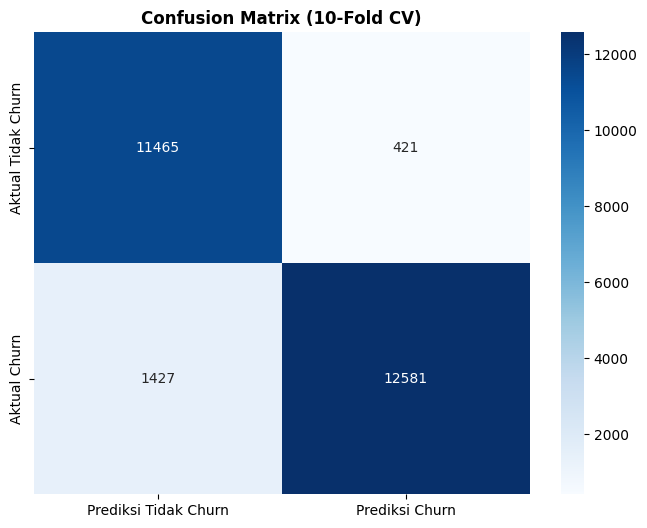

In [ ]:
# =============================================================================
# CELL 11: EVALUASI MENDALAM (SENSITIVITY & SPECIFICITY)
# =============================================================================
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("🔄 Menghitung Prediksi Cross-Validation untuk Matriks Evaluasi...")
# Mendapatkan hasil prediksi dari 10-Fold CV
y_pred_cv = cross_val_predict(dt_model, X_train_scaled, y_train, cv=skf)

# Menghitung Confusion Matrix
cm_cv = confusion_matrix(y_train, y_pred_cv)
tn, fp, fn, tp = cm_cv.ravel()

# Menghitung Metrik
sensitivity = tp / (tp + fn)  # Sama dengan Recall untuk kelas positif
specificity = tn / (tn + fp)  # Recall untuk kelas negatif

print("\n" + "="*60)
print("📈 METRIK EVALUASI: SENSITIVITY & SPECIFICITY (10-Fold CV)")
print("="*60)
print(f"Sensitivity (Recall Positif) : {sensitivity:.4f} ({sensitivity*100:.1f}%)")
print(f"Specificity (Recall Negatif) : {specificity:.4f} ({specificity*100:.1f}%)")
print("-"*60)
print("Interpretasi:")
print(f"- {sensitivity*100:.1f}% pelanggan yang BENAR-BENAR CHURN berhasil ditebak oleh model.")
print(f"- {specificity*100:.1f}% pelanggan yang TIDAK CHURN berhasil ditebak dengan benar.")

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prediksi Tidak Churn', 'Prediksi Churn'], 
            yticklabels=['Aktual Tidak Churn', 'Aktual Churn'])
plt.title('Confusion Matrix (10-Fold CV)', fontweight='bold')
plt.show()


🔄 Menyiapkan Evaluasi untuk XGBOOST...

📊 HASIL CROSS-VALIDATION (10-Fold) - XGBOOST
Rata-rata Akurasi      : 0.9332 (+/- 0.0099)

📈 METRIK EVALUASI: SENSITIVITY & SPECIFICITY - XGBOOST
Sensitivity (Recall Positif) : 0.9534 (95.3%)
Specificity (Recall Negatif) : 0.9093 (90.9%)


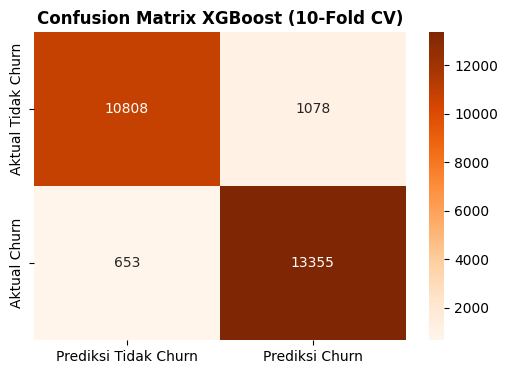

In [ ]:
# =============================================================================
# CELL 12: EVALUASI MENDALAM KHUSUS MODEL XGBOOST
# =============================================================================
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("🔄 Menyiapkan Evaluasi untuk XGBOOST...")

# 1. Inisialisasi Model XGBoost
# Menggunakan parameter standar, bisa disesuaikan jika sudah di-tuning
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# 2. Proses Cross-Validation (K-Fold = 10 Stratified)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_xgb = cross_val_score(xgb_model, X_train_scaled, y_train, cv=skf, scoring='accuracy')

print("\n" + "="*60)
print("📊 HASIL CROSS-VALIDATION (10-Fold) - XGBOOST")
print("="*60)
print(f"Rata-rata Akurasi      : {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std() * 2:.4f})")

# 3. Prediksi dan Metrik (Sensitivity & Specificity)
y_pred_cv_xgb = cross_val_predict(xgb_model, X_train_scaled, y_train, cv=skf)
cm_xgb = confusion_matrix(y_train, y_pred_cv_xgb)
tn_x, fp_x, fn_x, tp_x = cm_xgb.ravel()

sensitivity_xgb = tp_x / (tp_x + fn_x)
specificity_xgb = tn_x / (tn_x + fp_x)

print("\n" + "="*60)
print("📈 METRIK EVALUASI: SENSITIVITY & SPECIFICITY - XGBOOST")
print("="*60)
print(f"Sensitivity (Recall Positif) : {sensitivity_xgb:.4f} ({sensitivity_xgb*100:.1f}%)")
print(f"Specificity (Recall Negatif) : {specificity_xgb:.4f} ({specificity_xgb*100:.1f}%)")

# Visualisasi Confusion Matrix XGBoost
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Prediksi Tidak Churn', 'Prediksi Churn'], 
            yticklabels=['Aktual Tidak Churn', 'Aktual Churn'])
plt.title('Confusion Matrix XGBoost (10-Fold CV)', fontweight='bold')
plt.show()


In [ ]:
# =============================================================================
# CELL 13: VISUALISASI RULE XGBOOST (POHON PERTAMA)
# =============================================================================
import xgboost as xgb
import matplotlib.pyplot as plt

print("🔄 Menarik aturan (rules) dari model XGBoost...")
# Melatih ulang model pada seluruh data training agar rule bisa diekstrak
xgb_model.fit(X_train_scaled, y_train)

# Karena XGBoost memiliki ratusan pohon, kita akan melihat representasi pohon pertama (Tree 0)
booster = xgb_model.get_booster()
try:
    booster.feature_names = list(feature_names) # Memasukkan nama fitur agar tidak sekadar f0, f1
except:
    pass

tree_dump = booster.get_dump()[0]

print("\n" + "="*60)
print("🌲 TEXT RULES DARI POHON PERTAMA (TREE 0) XGBOOST")
print("="*60)
print("Cara membaca: [Kondisi Fitur] yes=Cabang selanjutnya jika YA, no=Cabang jika TIDAK\n")
print(tree_dump)
print("-"*60)

print("Mencoba menggambar pohon secara visual (membutuhkan modul 'graphviz')...")
try:
    fig, ax = plt.subplots(figsize=(24, 12))
    xgb.plot_tree(xgb_model, num_trees=0, ax=ax, rankdir='LR')
    plt.title('Visualisasi Rule XGBoost (Pohon Ke-0)', fontsize=18, fontweight='bold')
    plt.show()
except Exception as e:
    print("\n⚠️ Gagal menggambar diagram pohon karena graphviz belum terinstall/terkonfigurasi di sistem OS Anda.")
    print(f"Pesan Error: {e}")
    print("\n💡 TIPS: Anda tetap bisa menganalisis jalannya logika XGBoost melalui 'TEXT RULES' di atas.")


🔄 Menarik aturan (rules) dari model XGBoost...

🌲 TEXT RULES DARI POHON PERTAMA (TREE 0) XGBOOST
Cara membaca: [Kondisi Fitur] yes=Cabang selanjutnya jika YA, no=Cabang jika TIDAK

0:[plan_tier<0.0794978812] yes=1,no=2,missing=2
	1:[session_minutes_90d<0.556818724] yes=3,no=4,missing=4
		3:leaf=0.517333031
		4:[avg_session_duration<-0.0477935076] yes=7,no=8,missing=8
			7:leaf=0.468579471
			8:[session_minutes_90d<0.61275202] yes=13,no=14,missing=14
				13:leaf=-0.195762783
				14:leaf=0.352444947
	2:[points_in_wallet<0.0429962352] yes=5,no=6,missing=6
		5:[points_in_wallet<-0.511360526] yes=9,no=10,missing=10
			9:[plan_tier<1.22886586] yes=15,no=16,missing=16
				15:leaf=-0.648458481
				16:[sentiment_score<1.1298933] yes=23,no=24,missing=24
					23:[points_in_wallet<-1.72276139] yes=33,no=34,missing=34
						33:leaf=0.121685408
						34:leaf=-0.35353294
					24:leaf=-0.631069064
			10:[plan_tier<1.22886586] yes=17,no=18,missing=18
				17:leaf=-0.515234113
				18:[avg_transaction_val